In [2]:
import numpy as np
import matplotlib.pyplot as plt
from prettytable import PrettyTable

In [3]:
def least_square_fitting(X, Y,X_axis,Y_axis,plot,params,sample):
    # TABLE DATA
    Σx2 = 0
    Σy = 0
    Σxy = 0
    Σx = 0
    count = 0
    Σxylist = []
    Σx2list = []
    Slno = [ ]

    for i in range(len(X)):
        Σx2 += X[i]**2
        Σx2list.append(round(X[i]**2,4))
        Σy += Y[i]
        Σxy += X[i]*Y[i]
        Σxylist.append(round(X[i]*Y[i],4))
        Σx += X[i]
        count += 1
        Slno.append(count)
    # Finding slope and intercept
    fit = np.polyfit(X,Y,1)
    A = fit[0]
    B = fit[1]
    def f(x):
      return A*x + B
    # Error analysis
    error_sum = 0
    for i in range(len(X)):
        error_sum += (Y[i] - f(X[i]))**2
    error_y = (error_sum/ (len(X) - 2))**0.5
    delta = len(X)*Σx2 - Σx**2
    error_slope = error_y * (len(X)/delta)**0.5
    error_intercept = error_y * (Σx2/delta)**0.5
    if params==True:
        #Printing slopes,intercepts and errors
        table2 = PrettyTable()
        table2.title = "Slope, Intercept and Errors"
        if sample=='Al':
            table2.add_row(["Slope (x10^-4)" , round(A*10000,3) ])
            table2.add_row(["Intercept (x10^-3)" , round(B*1000,3) ])
            table2.add_row(["Error in y (x10^-3)", round(error_y*1000,3) ])
            table2.add_row(["Delta" , round(delta,5) ])
            table2.add_row(["Error in slope (x10^-4)", round(error_slope*10000,5) ])
            table2.add_row(["Error in intercept (x10^-3)", round(error_intercept*1000,5) ])
            print(table2)
            print()
        elif sample=='n-Ge':
            table2.add_row(["Slope (x10^-2)" , round(A*100,3) ])
            table2.add_row(["Intercept (x10^-2)" , round(B*100,3) ])
            table2.add_row(["Error in y (x10^-2)", round(error_y*100,3) ])
            table2.add_row(["Delta" , round(delta,5) ])
            table2.add_row(["Error in slope (x10^-2)", round(error_slope*100,5) ])
            table2.add_row(["Error in intercept (x10^-2)", round(error_intercept*100,5) ])
            print(table2)
            print()
        elif sample=='n-Si':    
            table2.add_row(["Slope (x10^-4)" , round(A*10000,3) ])
            table2.add_row(["Intercept (x10^-4)" , round(B*10000,3) ])
            table2.add_row(["Error in y (x10^-4)", round(error_y*10000,3) ])
            table2.add_row(["Delta" , round(delta,5) ])
            table2.add_row(["Error in slope (x10^-4)", round(error_slope*10000,5) ])
            table2.add_row(["Error in intercept (x10^-4)", round(error_intercept*10000,5) ])
            print(table2)
            print()
        elif sample=='n-Ge_T':
            table2.add_row(["Slope" , round(A,3) ])
            table2.add_row(["Intercept" , round(B,3) ])
            table2.add_row(["Error in y", round(error_y,3) ])
            table2.add_row(["Delta" , round(delta,5) ])
            table2.add_row(["Error in slope", round(error_slope,5) ])
            table2.add_row(["Error in intercept", round(error_intercept,5) ])
            print(table2)
            print()

    if plot==True:
        #GRAPH PLOT
        plt.xlabel(X_axis)
        plt.ylabel(Y_axis)
        
        plt.grid()
        plt.scatter(X,Y,label='Data Points',s=20,c='darkblue')
        fit = np.polyfit(X,Y,1)
        x_fit = np.linspace(min(X),max(X),1000)
        y_fit = fit[1]+fit[0]*x_fit

        # display table(least square fitting)
        X_rounded = [round(i,4) for i in X]
        Y_rounded = [round(i,4) for i in Y]
        table = PrettyTable()
        table.field_names = ["Sl No.","X", "Y", "X^2", "XY"]
        table.add_rows(list(zip(Slno, X_rounded, Y_rounded, Σx2list, Σxylist)))
        table.add_row([" ",'','','',''])
        table.add_row(["Total -", round(Σx,4), round(Σy,4), round(Σx2,4), round(Σxy,4)])
        print(table)
        if sample=='Al':
            plt.plot(x_fit,y_fit,'--', color='r',label = f'Least-square fit line : y = ({round(A*10000,3)}±{round(error_slope*10000,3)})x$10^{{-4}}$ x + ({round(B*1000,3)}±{round(error_intercept*1000,3)})x$10^{{-3}}$')
            plt.title('Four Probe Method (Resistivity determination by linear regression) : Aluminium Sample')
        elif sample=='n-Ge':
            plt.plot(x_fit,y_fit,'--', color='r',label = f'Least-square fit line : y = ({round(A*100,3)}±{round(error_slope*100,3)})x$10^{{-2}}$ x + ({round(B*100,3)}±{round(error_intercept*100,3)})x$10^{{-2}}$')
            plt.title('Four Probe Method (Resistivity determination by linear regression) : n-Ge Sample')
        elif sample=='n-Si':
            plt.plot(x_fit,y_fit,'--', color='r',label = f'Least-square fit line : y = ({round(A*10000,3)}±{round(error_slope*10000,3)})x$10^{{-4}}$ x + ({round(B*10000,3)}±{round(error_intercept*10000,3)})x$10^{{-4}}$')
            plt.title('Four Probe Method (Resistivity determination by linear regression) : n-Si Sample')
        elif sample=='n-Ge_T':
            plt.plot(x_fit,y_fit,'--', color='r',label = f'Least-square fit line : y = ({round(A,3)}±{round(error_slope,3)})x + ({round(B,3)}±{round(error_intercept,3)})')
            plt.title('Four Probe Method (Temperature dependence) : n-Ge Sample ')
        plt.legend()
        plt.show()


+------------------------------------------+
|       Slope, Intercept and Errors        |
+-----------------------------+------------+
|           Field 1           |  Field 2   |
+-----------------------------+------------+
|        Slope (x10^-4)       |   4.055    |
|      Intercept (x10^-3)     |   -3.26    |
|     Error in y (x10^-3)     |   0.369    |
|            Delta            | 1171119.86 |
|   Error in slope (x10^-4)   |  0.01487   |
| Error in intercept (x10^-3) |  0.18767   |
+-----------------------------+------------+

+---------+--------+-------+-----------+----------+
|  Sl No. |   X    |   Y   |    X^2    |    XY    |
+---------+--------+-------+-----------+----------+
|    1    |  6.7   |   0   |   44.89   |   0.0    |
|    2    |  21.5  | 0.006 |   462.25  |  0.129   |
|    3    |   33   |  0.01 |    1089   |   0.33   |
|    4    |  59.1  |  0.02 |  3492.81  |  1.182   |
|    5    |  70.5  | 0.025 |  4970.25  |  1.7625  |
|    6    |  81.2  |  0.03 |  6593.44  |  2

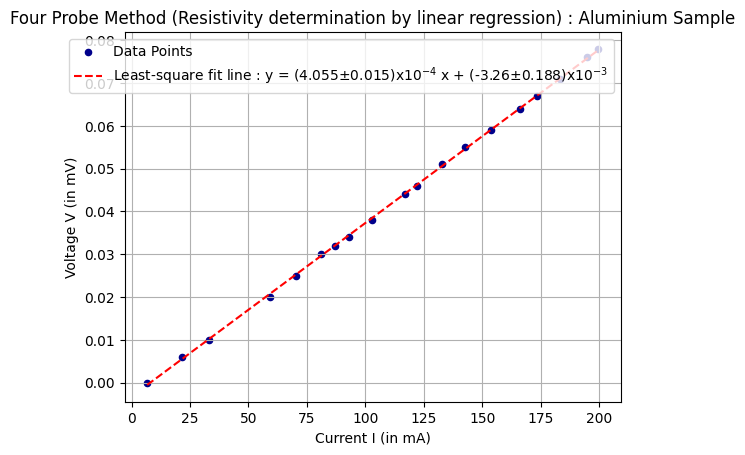

Resistivity of Aluminium sample is : (5.51362 ± 0.11214)x 10^{-5} ohm-cm
+----------------------------------------+
|      Slope, Intercept and Errors       |
+-----------------------------+----------+
|           Field 1           | Field 2  |
+-----------------------------+----------+
|        Slope (x10^-2)       |  9.135   |
|      Intercept (x10^-2)     |  -6.55   |
|     Error in y (x10^-2)     |  0.047   |
|            Delta            | 317.5139 |
|   Error in slope (x10^-2)   | 0.01177  |
| Error in intercept (x10^-2) | 0.02652  |
+-----------------------------+----------+

+---------+-------+-------+----------+--------+
|  Sl No. |   X   |   Y   |   X^2    |   XY   |
+---------+-------+-------+----------+--------+
|    1    |  0.71 |  0.0  |  0.5041  |  0.0   |
|    2    |  0.84 | 0.011 |  0.7056  | 0.0092 |
|    3    |  1.02 | 0.027 |  1.0404  | 0.0275 |
|    4    |  1.09 | 0.034 |  1.1881  | 0.0371 |
|    5    |  1.24 | 0.047 |  1.5376  | 0.0583 |
|    6    |  1.31 | 0.055 

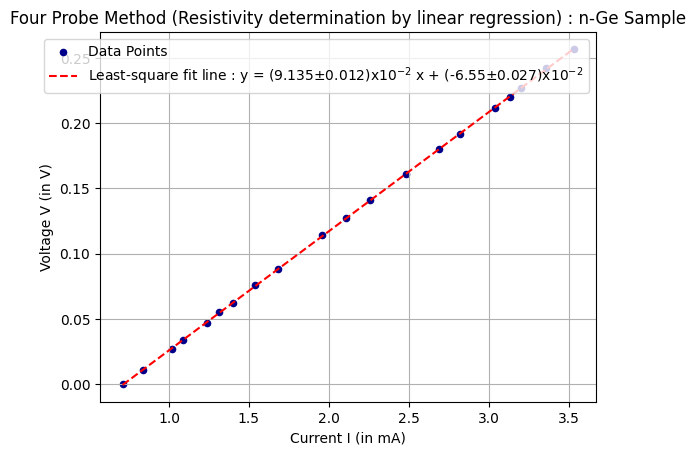

Resistivity of Germanium sample is : (20.70155 ± 0.41492) ohm-cm
+-------------------------------------------+
|        Slope, Intercept and Errors        |
+-----------------------------+-------------+
|           Field 1           |   Field 2   |
+-----------------------------+-------------+
|        Slope (x10^-4)       |    1.233    |
|      Intercept (x10^-4)     |    -4.895   |
|     Error in y (x10^-4)     |    3.212    |
|            Delta            | 78416777.96 |
|   Error in slope (x10^-4)   |   0.00211   |
| Error in intercept (x10^-4) |    0.8652   |
+-----------------------------+-------------+

+---------+---------+-------+------------+----------+
|  Sl No. |    X    |   Y   |    X^2     |    XY    |
+---------+---------+-------+------------+----------+
|    1    |    0    |  0.0  |     0      |   0.0    |
|    2    |   12.5  | 0.001 |   156.25   |  0.0125  |
|    3    |   38.5  | 0.004 |  1482.25   |  0.154   |
|    4    |   51.1  | 0.006 |  2611.21   |  0.3066  |
|   

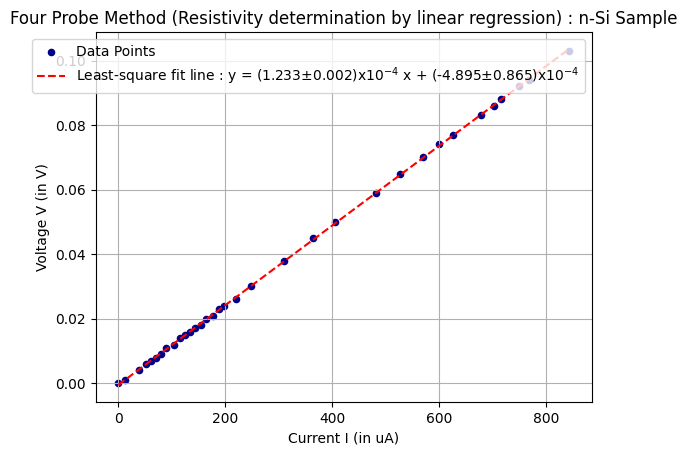

Resistivity of Silicon sample is : (27.942 ± 0.56067) ohm-cm


In [4]:
# Determination of Resistivity of diff. samples
# Al foil

V_al = [0,0.006,0.01,0.02,0.025,0.03,0.032,0.034,0.038,0.044,0.046,0.051,0.055,0.059,0.064,0.067,0.071,0.076,0.078] # in mV
I_al = [6.7,21.5,33,59.1,70.5,81.2,86.9,92.9,102.8,117,122,133,142.5,153.7,166.4,173.4,183.3,194.8,199.6] # in mA

least_square_fitting(I_al,V_al,'Current I (in mA)','Voltage V (in mV)',True,True,'Al')

# resistivity calculation for Al
slope_al = 4.055e-4 # in V/A
W_al = 0.03 # in cm
rho_al = slope_al*(np.pi*W_al/(np.log(2))) # in ohm-cm
error_slope_al = 0.015e-4 # in V/A
rel_err_W_al = 0.02 # 2% error in width measurement
error_rho_al = np.sqrt((error_slope_al/slope_al)**2 + (rel_err_W_al)**2) * rho_al
print(f"Resistivity of Aluminium sample is : ({round(rho_al*10**5,5)} ± {round(error_rho_al*10**5,5)})x 10^{{-5}} ohm-cm")


# n-Ge
V_ge = [0.068,0.079,0.095,0.102,0.115,0.123,0.13,0.144,0.156,0.182,0.195,0.209,0.229,0.248,0.260,0.280,0.288,0.295,0.31,0.325] # in V
V_corr = [V - V_ge[0] for V in V_ge] 
I_ge = [0.71,0.84,1.02,1.09,1.24,1.31,1.4,1.54,1.68,1.96,2.11,2.26,2.48,2.69,2.82,3.04,3.13,3.20,3.36,3.53] # in mA

least_square_fitting(I_ge,V_corr,'Current I (in mA)','Voltage V (in V)',True,True,'n-Ge')
# resistivity calculation for n-Ge
slope_ge = 9.135e-2 # in V/mA
W_ge = 0.05 # in cm
rho_ge = slope_ge*(np.pi*W_ge/(np.log(2))) # in ohm-cm
error_slope_ge = 0.012e-2 # in V/mA
rel_err_W_ge = 0.02 # 2% error in width measurement
error_rho_ge = np.sqrt((error_slope_ge/slope_ge)**2 + (rel_err_W_ge)**2) * rho_ge
print(f"Resistivity of Germanium sample is : ({round(rho_ge*10**3,5)} ± {round(error_rho_ge*10**3,5)}) ohm-cm")



# n-Si
V_si = [0.002,0.003,0.006,0.008,0.009,0.01,0.011,0.013,0.014,0.016,0.017,0.018,0.019,0.02,0.022,0.023,0.025,0.026,0.028,0.032,0.04,0.047,0.052,0.061,0.067,0.072,0.076,0.079,0.085,0.088,0.09,0.094,0.096,0.105]# in V
V_corr_si = [V - V_si[0] for V in V_si]
I_si = [0,12.5,38.5,51.1,61.2,70.6,80.3,90.1,105.1,114.7,124.5,133.9,143.5,154,163.9,176.9,189.3,197.5,220,248,311,365,406,483,528,570,601,626,678,703,717,750,768,844] # in uA

least_square_fitting(I_si,V_corr_si,'Current I (in uA)','Voltage V (in V)',True,True,'n-Si')
# resistivity calculation for n-Si
slope_si = 1.233e-4 # in V/uA
W_si = 0.05 # in cm
rho_si = slope_si*(np.pi*W_si/(np.log(2))) # in ohm-cm
error_slope_si = 0.002e-4 # in V/uA
rel_err_W_si = 0.02 # 2% error in width measurement
error_rho_si = np.sqrt((error_slope_si/slope_si)**2 + (rel_err_W_si)**2) * rho_si
print(f"Resistivity of Silicon sample is : ({round(rho_si*10**6,5)} ± {round(error_rho_si*10**6,5)}) ohm-cm")


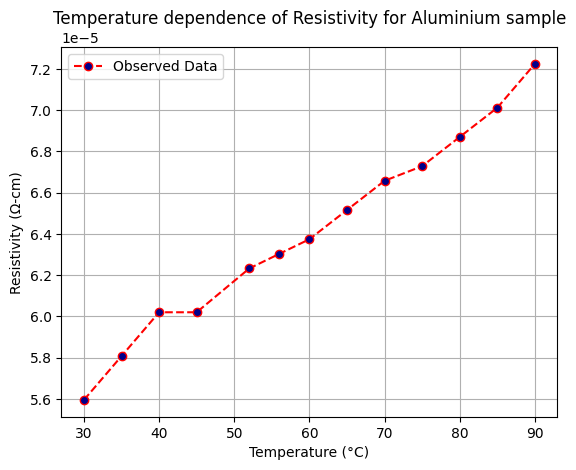

In [5]:
# Temperature dependence data for band gap of semiconductors
# Al sample
I_al_fix = 192 # in mA
S = 0.2 # in cm
W = 0.03 # in cm
G7 = (2*S/W)*np.log(2) # Geometric factor for 4-probe method
T_al = [30,35,40,45,52,56,60,65,70,75,80,85,90] # in degree Celsius
V_al_T = [0.079,0.082,0.085,0.085,0.088,0.089,0.09,0.092,0.094,0.095,0.097,0.099,0.102] # in mV
rho_0 = [(V_al_T[i]/I_al_fix)*2*np.pi*S for i in range(len(T_al))] # in Ohm-cm
rho = [rho_0[i]/G7 for i in range(len(rho_0))] # in Ohm-cm

plt.plot(T_al,rho,label='Observed Data',marker='o',mfc = 'darkblue',color='r',linestyle='--')
plt.xlabel('Temperature (°C)')
plt.ylabel('Resistivity (Ω-cm)')
plt.title('Temperature dependence of Resistivity for Aluminium sample')
plt.grid()
plt.legend()
plt.show()


+-------------------------------+
|  Slope, Intercept and Errors  |
+--------------------+----------+
|      Field 1       | Field 2  |
+--------------------+----------+
|       Slope        | 4219.377 |
|     Intercept      | -16.857  |
|     Error in y     |  0.058   |
|       Delta        |  1e-05   |
|   Error in slope   | 78.01491 |
| Error in intercept | 0.19795  |
+--------------------+----------+

+---------+--------+----------+--------+---------+
|  Sl No. |   X    |    Y     |  X^2   |    XY   |
+---------+--------+----------+--------+---------+
|    1    | 0.0029 | -4.6973  |  0.0   | -0.0136 |
|    2    | 0.0028 | -4.9522  |  0.0   |  -0.014 |
|    3    | 0.0028 | -5.2421  |  0.0   | -0.0144 |
|    4    | 0.0027 | -5.5413  |  0.0   | -0.0148 |
|    5    | 0.0026 | -5.8685  |  0.0   | -0.0152 |
|    6    | 0.0025 | -6.1038  |  0.0   | -0.0155 |
|    7    | 0.0025 | -6.3581  |  0.0   | -0.0157 |
|    8    | 0.0024 | -6.5945  |  0.0   |  -0.016 |
|    9    | 0.0024 | -6.8602  

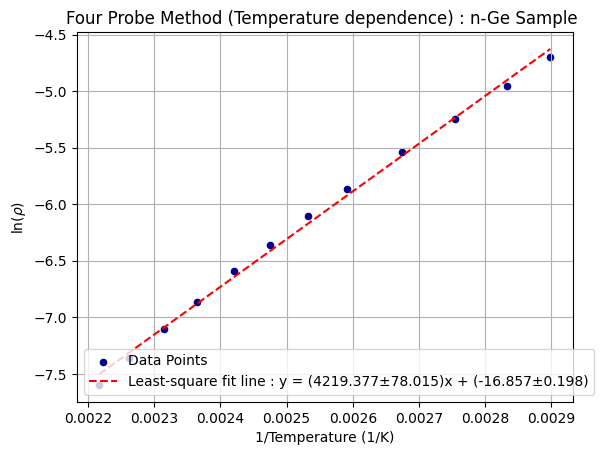

Band gap of n-Ge sample is : (0.727 ± 0.013) eV


In [8]:
# for n-Ge sample temperature dependence

I_al_fix = 4.97 # in mA
W = 0.05 # in cm
S = 0.2 # in cm
G7 = (2*S/W)*np.log(2) # Geometric factor for 4-probe method

T_ge = [72,80,90,101,113,122,131,140,150,159,169,178] # in degree Celsius
V_ge_T = [0.2,0.155,0.116,0.086,0.062,0.049,0.038,0.03,0.023,0.018,0.014,0.011] # in V
rho_0_ge = [(V_ge_T[i]/I_al_fix)*2*np.pi*S for i in range(len(T_ge))] # in Ohm-cm
rho_ge = [rho_0_ge[i]/G7 for i in range(len(rho_0_ge))] # in Ohm-cm
X = [1/(T+273) for T in T_ge] # in 1/K
Y = [np.log(rho) for rho in rho_ge]
least_square_fitting(X,Y,'1/Temperature (1/K)','ln($\\rho$)',True,True,'n-Ge_T') 

# band gap calculation for n-Ge sample
k = 8.617e-5 # in eV/K
slope = 4219.377 # from linear regression
Eg = 2*k*slope # in eV
error_Eg = 2*k*78.015 # in eV
print(f"Band gap of n-Ge sample is : ({round(Eg,3)} ± {round(error_Eg,3)}) eV")